In [1]:
# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp
from scipy.stats import randint, uniform

# 머신러닝 
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, r2_score, mean_squared_error, mean_absolute_error, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score, balanced_accuracy_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from lightgbm import LGBMClassifier, LGBMRegressor


# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [2]:
# 1. 데이터 로드
df = pd.read_csv('data/merged_final_data.csv')

df['total_price'] = df['price'] + df['freight_value']
df['freight_delay_penalty'] = df['freight_value'] * df['delay_days']
df['price_delay_penalty'] = df['price'] * df['delay_days']
df['total_delay_penalty'] = df['total_price'] * df['delay_days']
df['freight_distance_interaction'] = df['freight_value'] * df['distance_km']
df['delivery_freight_cost'] = df['delivery_days'] * df['freight_value']
df['is_weekend_purchase'] = df['order_purchase_dayofweek'].isin(['saturday', 'sunday']).astype(int)

# 2. 불필요한 컬럼 제거 (ID, 시간, 타겟과 겹치는 변수 등)
drop_cols = [
    'order_id', 'customer_id', 'customer_unique_id', 'seller_id', 
    'customer_city', 'seller_city', 'shipping_limit_date'
]
X = df.drop(columns=['review_score'] + drop_cols, errors='ignore')
y = df['review_score']

# 3. 원본 데이터 상태에서 분리 (원핫 인코딩 수행 전)
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid, test_size=0.2, random_state=42, stratify=y_train_valid
)

# 4. 수치형/범주형 컬럼 분리
num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()

# 5. 전처리 파이프라인 정의
numeric_transformer = SimpleImputer(strategy='median') # 수치형은 중앙값으로 결측치 대체
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # 범주형은 최빈값으로 대체
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # 새로운 범주 등장 시 무시
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

### 하이퍼파라미터 튜닝

In [3]:

# import optuna
# from xgboost import XGBRegressor
# from sklearn.metrics import mean_squared_error
# import numpy as np

# # 1. Optuna 목적 함수(Objective Function) 정의
# def objective(trial):
#     # 튜닝할 하이퍼파라미터의 탐색 범위 설정 (과적합 방지에 초점)
#     param = {
#         'n_estimators': 3000, # 최대 트리는 넉넉하게 잡고 조기 종료로 제어
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
#         'max_depth': trial.suggest_int('max_depth', 3, 8), # 너무 깊어지지 않도록 3~8로 제한
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
#         'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),  # L1 정규화 (피처 솎아내기)
#         'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True), # L2 정규화 (가중치 누르기)
#         'tree_method': 'hist', 
#         'random_state': 42,
#         'n_jobs': -1,
#         'early_stopping_rounds': 50,
#         'eval_metric': 'rmse'
#     }

#     # 제안된 파라미터로 모델 생성
#     model = XGBRegressor(**param)
    
#     # 모델 학습 (조기 종료 적용)
#     model.fit(
#         X_train, y_train,
#         eval_set=[(X_valid, y_valid)],
#         verbose=False # 튜닝 중에는 로그가 너무 많아지므로 숨김 처리
#     )
    
#     # 검증 데이터(Validation)로 예측 후 RMSE 계산
#     preds = np.clip(model.predict(X_valid), 1, 5)
#     rmse = np.sqrt(mean_squared_error(y_valid, preds))
    
#     # Optuna는 이 반환된 RMSE 값이 '최소화'되는 방향으로 파라미터를 찾아갑니다.
#     return rmse

# # 2. Optuna Study 생성 및 실행
# print("하이퍼파라미터 튜닝 시작")
# study = optuna.create_study(direction='minimize') # 목표: RMSE 최소화

# # n_trials: 몇 번의 파라미터 조합을 테스트해 볼 것인지 설정 (시간 여유에 따라 50~100 추천)
# study.optimize(objective, n_trials=50) 

# # 3. 최적의 파라미터 결과 출력
# print("\n=== 튜닝 완료! 가장 성능이 좋았던 Best 파라미터 ===")
# best_params = study.best_trial.params
# for key, value in best_params.items():
#     print(f"    '{key}': {value},")

# print(f"\n이때의 Validation RMSE: {study.best_trial.value:.4f}")

# # best 파라미터 값
# #     learning_rate=0.03,      
# #     max_depth=3,
# #     min_child_weight=3,             
# #     subsample=0.767,
# #     colsample_bytree=0.844,
# #     reg_alpha=0.029,
# #     reg_lambda=6.716,

XGBoost 회귀 모델 학습을 시작합니다...
학습 자동 종료 완료! (최적의 트리 개수: 2998)


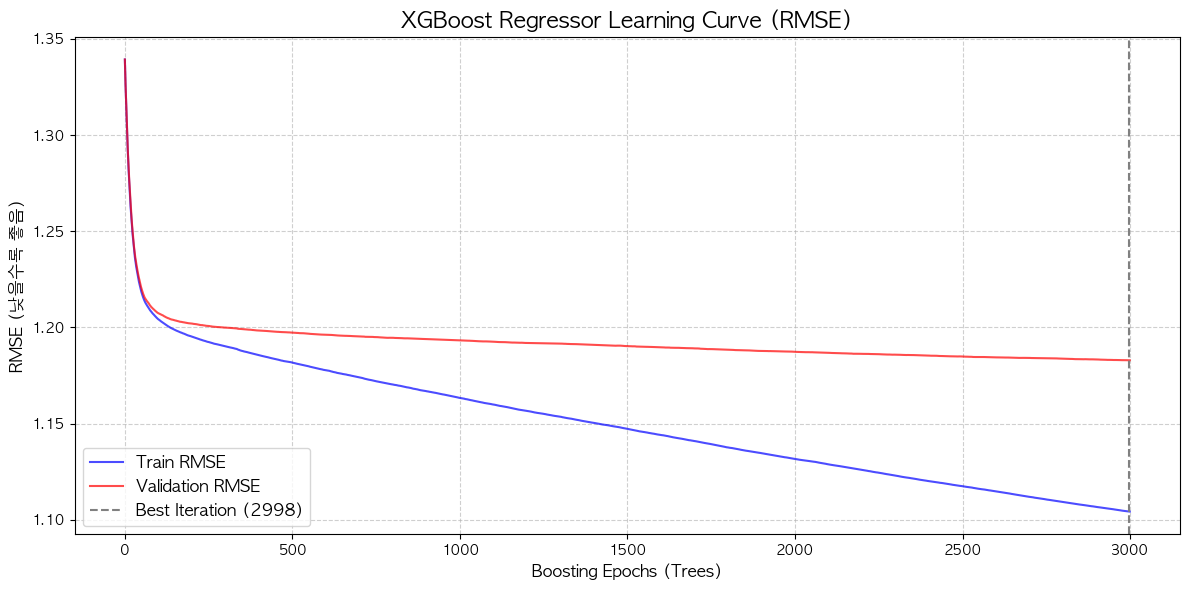


=== 최종 평가 결과 (Validation) ===
RMSE: 1.1828
MAE: 0.9106
R2 Score: 0.2287


In [4]:
# 1. Pipeline 내부의 preprocessor만 단독으로 꺼내어 데이터를 직접 변환
X_train_transformed = preprocessor.fit_transform(X_train)
X_valid_transformed = preprocessor.transform(X_valid)

# 2. XGBRegressor 모델 정의 (분류기의 logloss 대신 회귀용 rmse 사용)
xgb_model = XGBRegressor(
    n_estimators=3000,          # 넉넉하게 잡고 조기종료로 제어
    learning_rate=0.03078,
    max_depth=4,
    min_child_weight=20,
    reg_lambda=3.0,
    tree_method='hist',
    subsample=0.87330,           
    colsample_bytree=0.60638,    
    n_jobs=4,
    random_state=42,
    early_stopping_rounds=50,   # [핵심] 50번 동안 Valid 성능이 개선되지 않으면 자동 종료
    eval_metric='rmse'          # 평가 지표: RMSE
)

# 3. 모델 학습 (Train과 Valid 모두 eval_set에 넣어 에포크마다 기록)
print("XGBoost 회귀 모델 학습을 시작합니다...")
xgb_model.fit(
    X_train_transformed, 
    y_train,
    eval_set=[(X_train_transformed, y_train), (X_valid_transformed, y_valid)], 
    verbose=0             
)

print(f"학습 자동 종료 완료! (최적의 트리 개수: {xgb_model.best_iteration})")

# 4. 러닝 커브 (Learning Curve) 시각화
plt.figure(figsize=(12, 6))

# XGBoost는 evals_result() 내부에 학습 기록을 저장 (validation_0: Train, validation_1: Valid)
results = xgb_model.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)

# Train과 Valid의 RMSE 추이 시각화
plt.plot(x_axis, results['validation_0']['rmse'], label='Train RMSE', color='blue', alpha=0.7)
plt.plot(x_axis, results['validation_1']['rmse'], label='Validation RMSE', color='red', alpha=0.7)

plt.title("XGBoost Regressor Learning Curve (RMSE)", fontsize=16)
plt.xlabel("Boosting Epochs (Trees)", fontsize=12)
plt.ylabel("RMSE (낮을수록 좋음)", fontsize=12)

# 과적합 방지 및 최적 지점(Early Stopping) 수직선 표시
plt.axvline(x=xgb_model.best_iteration, color='gray', linestyle='--', label=f'Best Iteration ({xgb_model.best_iteration})')

plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 5. 예측 및 클리핑(Clipping) 처리 적용
y_pred_valid = xgb_model.predict(X_valid_transformed)
y_pred_valid = np.clip(y_pred_valid, 1, 5) # 1~5점 고정

# 6. 최종 성능 평가
rmse_valid = np.sqrt(mean_squared_error(y_valid, y_pred_valid))
mae_valid = mean_absolute_error(y_valid, y_pred_valid)
r2_valid = r2_score(y_valid, y_pred_valid)

print("\n=== 최종 평가 결과 (Validation) ===")
print(f"RMSE: {rmse_valid:.4f}")
print(f"MAE: {mae_valid:.4f}")
print(f"R2 Score: {r2_valid:.4f}")

In [5]:
# ==========================================
# Test 세트 최종 성능 평가
# ==========================================

# 1. Test 데이터 전처리 (반드시 Train 세트의 규칙만으로 변환)
# 주의: 절대 fit_transform을 사용하지 않고 transform만 사용합니다.
X_test_transformed = preprocessor.transform(X_test)

# 2. Test 데이터 예측 및 클리핑
y_pred_test = xgb_model.predict(X_test_transformed)
y_pred_test = np.clip(y_pred_test, 1, 5) # 1~5점 고정

# 3. Test 세트 평가 지표 계산
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("\n=== 최종 평가 결과 (Test) ===")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE: {mae_test:.4f}")
print(f"R2 Score: {r2_test:.4f}")


=== 최종 평가 결과 (Test) ===
RMSE: 1.1886
MAE: 0.9170
R2 Score: 0.2213
